In [2]:
import seaborn as sns
sidd=sns.load_dataset("tips")
print(sidd)


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [2]:
pip install seaborn


     -------------------------------------- 294.9/294.9 kB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install sklearn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates from a subpr

In [7]:
pip install scikit-learn

     ---------------------------------------- 8.3/8.3 MB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 36.6/36.6 MB 4.9 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 4.8 MB/s eta 0:00:00
     -------------------------------------- 458.9/458.9 kB 5.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

tips= sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
sidd=sidd.rename(columns={"sex":"Gender"})
sidd

,total_bill,tip,Gender,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [5]:
x = sidd[["total_bill","size"]]
y = sidd["size"]
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
len(x_train)
len(x_test)
len(x_train)
len(x_test)

model = LinearRegression()

model.fit(
    x_train,
    y_train
)
y_pred=model.predict(x_test)
mae=mean_absolute_error(
    y_test,
    y_pred
)

mae
# | **MAE Value** | **Interpretation**                                                |
# | ------------- | ----------------------------------------------------------------- |
# | **0.0**       | Perfect prediction (no error).                                    |
# | **0.1 – 0.5** | Excellent model. Predictions are very close to the actual values. |
# | **0.5 – 1.0** | Good model. Small prediction errors.                              |
# | **1.0 – 2.0** | Fair model. Predictions are reasonably close but can be improved. |
# | **&gt; 2.0**     | Poor model. Predictions are far from the actual values.           |


3.6705332650872524e-16

In [6]:
#Unsupervised Learning
from sklearn.cluster import KMeans
# features
x = sidd[["total_bill","tip"]]
#K-Means
model=KMeans(n_clusters=3,random_state=42)
sidd["cluster"]=model.fit_predict(x)
print(sidd.head())

   total_bill   tip  Gender smoker  day    time  size  cluster
0       16.99  1.01  Female     No  Sun  Dinner     2        1
1       10.34  1.66    Male     No  Sun  Dinner     3        1
2       21.01  3.50    Male     No  Sun  Dinner     3        0
3       23.68  3.31    Male     No  Sun  Dinner     2        0
4       24.59  3.61  Female     No  Sun  Dinner     4        0


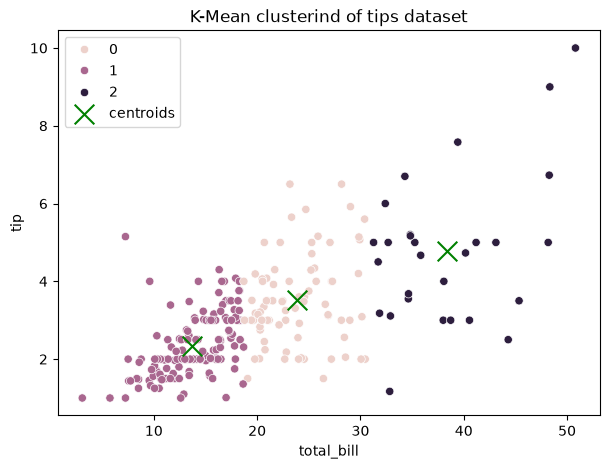

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=sidd,
    x="total_bill",
    y="tip",
    hue="cluster")
#plot cluster center
center = model.cluster_centers_
plt.scatter(
    center[:,0],
    center[:,1],
    c="green",
    s=200,
    marker="x",
    label="centroids")
plt.title("K-Mean clusterind of tips dataset")
plt.legend()
plt.show()

In [8]:
sidd=sns.load_dataset("titanic")
sidd

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
